**Задача:** предсказать класс полезности продукта (nutri-score - от 0=А как самого полезного до 4=Е как самого вредного)

- обучить не менее трех полносвязных нейронных сетей с различной архитектурой (по глубине сети, размеру скрытых слоев, функциям активации, наличию регуляризации) для предсказания класса полезности продукта на трейне, посмотреть разные гиперпараметры на валидационной выборке и выбрать лучшую модель по тестовой выборке.

In [1]:
import pandas as pd

In [2]:
!pip install wandb mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import mlflow
import dagshub
from tqdm import tqdm

In [4]:
from sklearn.metrics import f1_score

In [5]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
X_val = pd.read_csv('X_val.csv')
X_train.head(3)

,energy_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,fat_cal_raio,protein_cal_raio,carbs_cal_raio,saturated_fat_ratio
0,-0.999981,-0.937167,-0.738675,-0.142176,-0.871495,-0.322373,0.042519,-0.040444,-0.063084,-0.867267
1,0.353973,-1.067920,-0.825973,-0.972703,2.299405,1.791778,0.048087,0.049563,-0.091742,1.337873
2,-1.139784,-0.773727,-0.241075,0.300772,-0.767531,-0.897652,-0.051558,0.013228,0.005697,-0.396739


In [6]:
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')
y_val = pd.read_csv('y_val.csv')
y_train.head(3)

,healthy
0,1
1,3
2,0


In [7]:
from torch.utils.data import TensorDataset, DataLoader
import torch

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values.squeeze(), dtype=torch.long)
y_val_tensor = torch.tensor(y_val.values.squeeze(), dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values.squeeze(), dtype=torch.long)

In [8]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [9]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
dagshub.init(repo_owner='leosh1d', repo_name='gp5', mlflow=True)

Initialized MLflow to track repo "leosh1d/gp5"

Repository leosh1d/gp5 initialized!

In [12]:
mlflow.set_tracking_uri("https://dagshub.com/leosh1d/gp5.mlflow/")
mlflow.set_experiment("MLP exp")

<Experiment: artifact_location='mlflow-artifacts:/8ed0cede01a34cf8bfea281e4745e8f3', creation_time=1781571320014, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781571320014, lifecycle_stage='active', name='MLP exp', tags={}, trace_location=None, workspace='default'>

В качестве метрик для классификации рассмотрим не только классику accuracy, но и f1 (показательна, совмещает и полноту, и точность). Тк классификация многоклассовая, то нужно усреднение. Будем использовать macro (для метрики считается её значение по каждому классу независимо, а затем берется среднее арифметическое), тк нам одинаково важны все классы, независимо от их частоты, то этот подход полезен, тк не учитывает дисбаланс классов, все они равны по значимости.

(для выбора метрик основывались на [этой статье](https://www.sostav.ru/blogs/161815/64812))

In [13]:
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train()
    total = 0
    total_loss = 0
    correct = 0

    n_ex = len(train_loader)

    y_true = []
    y_pred = []

    for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=n_ex):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad() # обнуляем градиенты
        output = model(data)
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()

        train_loss = criterion(output, target) # считаем лосс
        train_loss.backward() # обратный проход
        optimizer.step() # делаем шаг оптимизатором

        total_loss += train_loss.item() * data.size(0)
        total += target.size(0)

        y_true.extend(target.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    tqdm.write(
    f'\nEpoch {epoch}: Train set: Average loss={avg_loss:.4f}, Accuracy={accuracy * 100:.2f}%,F1_macro={f1_macro:.4f}')


    return avg_loss, accuracy, f1_macro

In [14]:
def test(model, device, test_loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    y_true = []
    y_pred = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target)
            total_loss += test_loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)

            y_true.extend(target.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    tqdm.write(
        f'Test set: Average loss={avg_loss:.4f}, Accuracy={accuracy * 100:.2f}%, F1_macro={f1_macro:.4f}')

    return avg_loss, accuracy, f1_macro

In [15]:
def launch(model,model_name,device,train_loader,val_loader,test_loader,optimizer,criterion,num_epochs):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    with mlflow.start_run(run_name=model_name) as run:
        mlflow.log_params({
            "model_name": model_name,
            "num_epochs": num_epochs,
            "lr": LR,
            "batch_size": BATCH_SIZE,
            "num_params": sum(p.numel() for p in model.parameters())})

        for epoch in range(1, num_epochs + 1):
            print('\nEpoch:', epoch)

            train_loss, train_acc, train_f1 = train(model,device,train_loader,optimizer,criterion,epoch)

            val_loss, val_acc, val_f1 = test(model,device,val_loader,criterion)
        test_loss, test_acc, test_f1 = test(model,device,test_loader,criterion)
        mlflow.log_metrics({"test_loss": test_loss, "test_accuracy": test_acc, "test_f1": test_f1})
        mlflow.pytorch.log_model(model, name="model")

    print('Training is ended!')

In [16]:
NUM_EPOCHS=10
LR =0.002
NUM_CLASSES=5

Сначала LR был 0.02, но качество было низкое - слишком большой шаг, перескакивал.

### Первая простая модель
Используем её как старт, от которого отталкиваемся)

Прочла в [статье](https://habr.com/ru/articles/727506/?ysclid=mqfq5z6z72930987544), что для многоклассовой классификации подходит функция активации softmax.

In [17]:
class MLP_simple(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(10, 64), # у нас 10 признаков
            nn.Softmax(dim=1),
            nn.Linear(64, 5), # и 5 классов
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.model(x)

Для решения задачи многоклассовой классификации используют функцию потерь
кросс-энтропия.

В качестве оптимизатора берем адаптивный метод, умеющий динамически настраивать скорость обучения для каждого параметра на основе истории градиентов - Adam, тк Adam часто сходится быстрее других методов и менее чувствителен к выбору гиперпараметров за счет того, что оценивает первый и второй моменты градиентов (среднее и несмещенную дисперсию) и использует их для масштабирования скорости обучения [[статья](https://habr.com/ru/companies/magnus-tech/articles/840902/)].

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MLP_simple().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

launch(model,'MLP_simple',device,train_loader,val_loader,test_loader,optimizer,criterion,NUM_EPOCHS)


Epoch: 1


100%|██████████| 6509/6509 [00:10<00:00, 637.83it/s]



Epoch 1: Train set: Average loss=1.3209, Accuracy=61.20%,F1_macro=0.5659
Test set: Average loss=1.2438, Accuracy=68.22%, F1_macro=0.6626

Epoch: 2


100%|██████████| 6509/6509 [00:17<00:00, 381.60it/s]



Epoch 2: Train set: Average loss=1.2258, Accuracy=69.44%,F1_macro=0.6776
Test set: Average loss=1.2147, Accuracy=70.08%, F1_macro=0.6850

Epoch: 3


...


Epoch 9: Train set: Average loss=1.1613, Accuracy=74.63%,F1_macro=0.7394
Test set: Average loss=1.1627, Accuracy=74.34%, F1_macro=0.7342

Epoch: 10


100%|██████████| 6509/6509 [00:09<00:00, 651.54it/s]



Epoch 10: Train set: Average loss=1.1595, Accuracy=74.74%,F1_macro=0.7405
Test set: Average loss=1.1605, Accuracy=74.57%, F1_macro=0.7395
Test set: Average loss=1.1600, Accuracy=74.78%, F1_macro=0.7421


2026/06/16 07:55:25 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/16 07:55:26 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/16 07:55:33 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to m

🏃 View run MLP_simple at: https://dagshub.com/leosh1d/gp5.mlflow/#/experiments/1/runs/14ed9d5270d744d5a2fdb661e252294d
🧪 View experiment at: https://dagshub.com/leosh1d/gp5.mlflow/#/experiments/1
Training is ended!


### Вторая модель более глубокая
train и val примерно одинаковые, но качество среднее - значит: модель не переобучилась, но ей, возможно, не хватает мощности. Поэтому увеличим число слоев.

и при этом добавим дропаут, чтобы переобучения не было.

А чтобы добавить нелинейности, в скрытом слое заменим функцию активации на релу.

In [124]:
class MLP_deep_norm(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(10, 64), # у нас 10 признаков
            nn.Softmax(dim=1),
            nn.BatchNorm1d(64),
            nn.Linear(64, 32),
            nn.Softmax(dim=1),
            nn.Linear(32, 16),
            nn.LeakyReLU(),
            nn.Dropout(0.05),
            nn.Linear(16, 8),
            nn.LeakyReLU(),
            nn.Linear(8, 5), # и 5 классов
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.model(x)

In [37]:
class MLP_deep(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(10, 64), # у нас 10 признаков
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.05),

            nn.Linear(32, 5), # и 5 классов
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.model(x)

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MLP_deep().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

launch(model,'MLP_deep',device,train_loader,val_loader,test_loader,optimizer,criterion,
    NUM_EPOCHS)


Epoch: 1


100%|██████████| 6509/6509 [00:12<00:00, 520.00it/s]



Epoch 1: Train set: Average loss=1.1924, Accuracy=71.31%,F1_macro=0.7044
Test set: Average loss=1.1665, Accuracy=73.44%, F1_macro=0.7275

Epoch: 2


100%|██████████| 6509/6509 [00:12<00:00, 519.71it/s]



Epoch 2: Train set: Average loss=1.1634, Accuracy=73.88%,F1_macro=0.7320
Test set: Average loss=1.1582, Accuracy=74.34%, F1_macro=0.7383

Epoch: 3


...


Epoch 9: Train set: Average loss=1.1444, Accuracy=75.85%,F1_macro=0.7517
Test set: Average loss=1.1447, Accuracy=75.84%, F1_macro=0.7505

Epoch: 10


100%|██████████| 6509/6509 [00:20<00:00, 315.17it/s]



Epoch 10: Train set: Average loss=1.1436, Accuracy=75.93%,F1_macro=0.7523
Test set: Average loss=1.1387, Accuracy=76.40%, F1_macro=0.7577
Test set: Average loss=1.1369, Accuracy=76.61%, F1_macro=0.7597


2026/06/16 08:46:31 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/16 08:46:31 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/16 08:46:37 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to m

🏃 View run MLP_deep at: https://dagshub.com/leosh1d/gp5.mlflow/#/experiments/1/runs/3ec6de8adaa94328b9a0d466ddd3882b
🧪 View experiment at: https://dagshub.com/leosh1d/gp5.mlflow/#/experiments/1
Training is ended!


### Третья модель с нормализацией

Увеличение числа слоев означает увеличение времени обучения. Так что используем еще Batch Normalization, которая предназначена для улучшения скорости, производительности и стабильности обучения нейронных сетей ([статья](https://habr.com/ru/companies/mvideo/articles/782360/?ysclid=mqfviy4qc0569167039)).


In [42]:
class MLP_deep_norm(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(10, 64), # у нас 10 признаков
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.05),

            nn.Linear(32, 5), # и 5 классов
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.model(x)

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MLP_deep_norm().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

launch(model,'MLP_deep_norm',device,train_loader,val_loader,test_loader,optimizer,criterion,NUM_EPOCHS)


Epoch: 1


100%|██████████| 6509/6509 [00:15<00:00, 432.86it/s]



Epoch 1: Train set: Average loss=1.2471, Accuracy=65.39%,F1_macro=0.6460
Test set: Average loss=1.1932, Accuracy=70.84%, F1_macro=0.6916

Epoch: 2


100%|██████████| 6509/6509 [00:14<00:00, 452.14it/s]



Epoch 2: Train set: Average loss=1.2279, Accuracy=67.18%,F1_macro=0.6654
Test set: Average loss=1.1850, Accuracy=71.49%, F1_macro=0.7038

Epoch: 3


...


Epoch 9: Train set: Average loss=1.2045, Accuracy=69.64%,F1_macro=0.6898
Test set: Average loss=1.2012, Accuracy=69.84%, F1_macro=0.6960

Epoch: 10


100%|██████████| 6509/6509 [00:14<00:00, 445.95it/s]



Epoch 10: Train set: Average loss=1.2049, Accuracy=69.60%,F1_macro=0.6899
Test set: Average loss=1.1757, Accuracy=72.59%, F1_macro=0.7213
Test set: Average loss=1.1764, Accuracy=72.45%, F1_macro=0.7202


2026/06/16 08:54:03 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/16 08:54:03 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/16 08:54:10 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to m

🏃 View run MLP_deep_norm at: https://dagshub.com/leosh1d/gp5.mlflow/#/experiments/1/runs/ce44a85e3ac446768151dd44a60ced1a
🧪 View experiment at: https://dagshub.com/leosh1d/gp5.mlflow/#/experiments/1
Training is ended!


### Четвертая модель с Residual connection

Нашла такую [статью](https://habr.com/ru/articles/982820/?ysclid=mqg0p5eyyf688325582) и [гитхаб](https://github.com/david-thrower/residual_MLP_Tests?ysclid=mqfzul00kt561543434). Здесь говорится, что в том числе для многоклассовой классификации подходит.

Отличается от обычных MLP тем, появляется дополнительный путь передачи информации между слоями (вход идет двумя путями). Модель как бы лучше запоминает, что было раньше (некие исторические корни) и работает стабильнее. Residual connection борется с затухающими градиентами и значительно улучшает обучение модели.

In [51]:
class ResidualBlock(nn.Module):
    def __init__(self, hidden_dim, dropout=0.02):
        super().__init__()

        self.block = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),

        )

        self.activation = nn.ReLU()

    def forward(self, x):
        residual = x
        out = self.block(x)
        out = out + residual
        out = self.activation(out)
        return out


class ResidualMLP(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=64, num_classes=5, dropout=0.02):
        super().__init__()

        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )

        self.res_blocks = nn.Sequential(
            ResidualBlock(hidden_dim, dropout)
        )

        self.output_layer = nn.Sequential(nn.Linear(hidden_dim, num_classes),
                                          nn.Softmax(dim=1))

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_blocks(x)
        x = self.output_layer(x)
        return x

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResidualMLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

launch(model,'ResidualMLP',device,train_loader,val_loader,test_loader,optimizer,criterion,NUM_EPOCHS)


Epoch: 1


100%|██████████| 6509/6509 [00:18<00:00, 356.86it/s]



Epoch 1: Train set: Average loss=1.2402, Accuracy=65.91%,F1_macro=0.6519
Test set: Average loss=1.1733, Accuracy=72.73%, F1_macro=0.7210

Epoch: 2


100%|██████████| 6509/6509 [00:30<00:00, 213.85it/s]



Epoch 2: Train set: Average loss=1.2153, Accuracy=68.47%,F1_macro=0.6783
Test set: Average loss=1.1645, Accuracy=73.69%, F1_macro=0.7254

Epoch: 3


...


Epoch 9: Train set: Average loss=1.1771, Accuracy=72.37%,F1_macro=0.7183
Test set: Average loss=1.1425, Accuracy=75.92%, F1_macro=0.7559

Epoch: 10


100%|██████████| 6509/6509 [00:18<00:00, 356.87it/s]



Epoch 10: Train set: Average loss=1.1758, Accuracy=72.49%,F1_macro=0.7197
Test set: Average loss=1.1971, Accuracy=70.27%, F1_macro=0.7030
Test set: Average loss=1.1974, Accuracy=70.22%, F1_macro=0.7029


2026/06/16 09:22:33 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/16 09:22:33 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/16 09:22:39 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to m

🏃 View run ResidualMLP at: https://dagshub.com/leosh1d/gp5.mlflow/#/experiments/1/runs/e552cad23d534271bc6dbcfa0e06b00d
🧪 View experiment at: https://dagshub.com/leosh1d/gp5.mlflow/#/experiments/1
Training is ended!


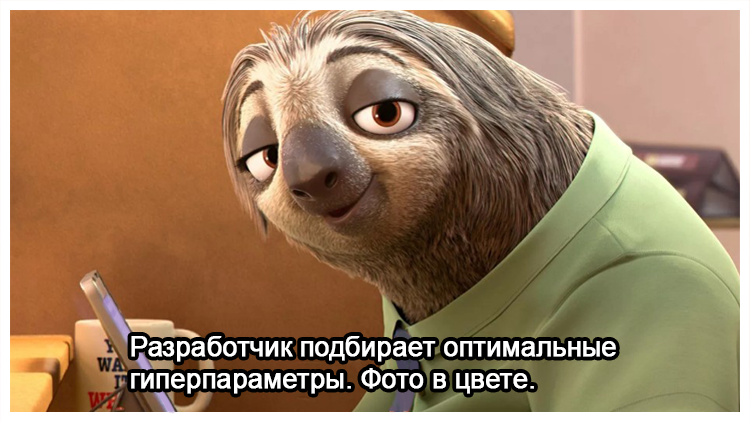